In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [34]:
df = pd.read_csv('Social_Network_Ads.csv')

In [35]:
df.head(10)

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0
5,15728773,Male,27,58000,0
6,15598044,Female,27,84000,0
7,15694829,Female,32,150000,1
8,15600575,Male,25,33000,0
9,15727311,Female,35,65000,0


In [37]:
df = df.iloc[:,2:]
df

,Age,EstimatedSalary,Purchased
0,19,19000,0
1,35,20000,0
2,26,43000,0
3,27,57000,0
4,19,76000,0
...,...,...,...
395,46,41000,1
396,51,23000,1
397,50,20000,1
398,36,33000,0


train_test_split

In [95]:
from sklearn.model_selection import train_test_split
x_train,x_test , y_train , y_test = train_test_split(
    df.drop('Purchased',axis=1),  #Features (x) : all columns except 'Puchased'
    df['Purchased'],              #Target (y) : the Purchased column  
    test_size = 0.3,              # 30% of data for testing, 70% for training
    random_state = 0)              # Ensures reproducibility of the split

In [96]:
x_train.shape , x_test.shape

((280, 2), (120, 2))

# Standard Scaler

In [72]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
#fiting the training data
scaler.fit(x_train)
#tranforming the data and test data
x_train_scaled = scaler.transform(x_train)
x_test_scaled = scaler.transform(x_test)

In [73]:
scaler.mean_

array([3.78642857e+01, 6.98071429e+04])

In [74]:
x_train_scaled

array([[-1.1631724 , -1.5849703 ],
       [ 2.17018137,  0.93098672],
       [ 0.0133054 ,  1.22017719],
       [ 0.20938504,  1.07558195],
       [ 0.40546467, -0.48604654],
       [-0.28081405, -0.31253226],
       [ 0.99370357, -0.8330751 ],
       [ 0.99370357,  1.8563962 ],
       [ 0.0133054 ,  1.24909623],
       [-0.86905295,  2.26126285],
       [-1.1631724 , -1.5849703 ],
       [ 2.17018137, -0.80415605],
       [-1.35925203, -1.46929411],
       [ 0.40546467,  2.2901819 ],
       [ 0.79762394,  0.75747245],
       [-0.96709276, -0.31253226],
       [ 0.11134522,  0.75747245],
       [-0.96709276,  0.55503912],
       [ 0.30742485,  0.06341534],
       [ 0.69958412, -1.26686079],
       [-0.47689368, -0.0233418 ],
       [-1.7514113 ,  0.3526058 ],
       [-0.67297331,  0.12125343],
       [ 0.40546467,  0.29476771],
       [-0.28081405,  0.06341534],
       [-0.47689368,  2.2901819 ],
       [ 0.20938504,  0.03449629],
       [ 1.28782302,  2.20342476],
       [ 0.79762394,

In [75]:
# since StandardScaler returns array so we will convert it to dataframes first then use it
x_train_scaled = pd.DataFrame(x_train_scaled,columns = ['Age','EstimatedSalary'])

In [76]:
x_train.describe()

,Age,EstimatedSalary
count,280.000000,280.000000
mean,37.864286,69807.142857
std,10.218201,34641.201654
min,18.000000,15000.000000
25%,30.000000,43000.000000
50%,37.000000,70500.000000
75%,46.000000,88000.000000
max,60.000000,150000.000000


# visualising effect of scaling on data

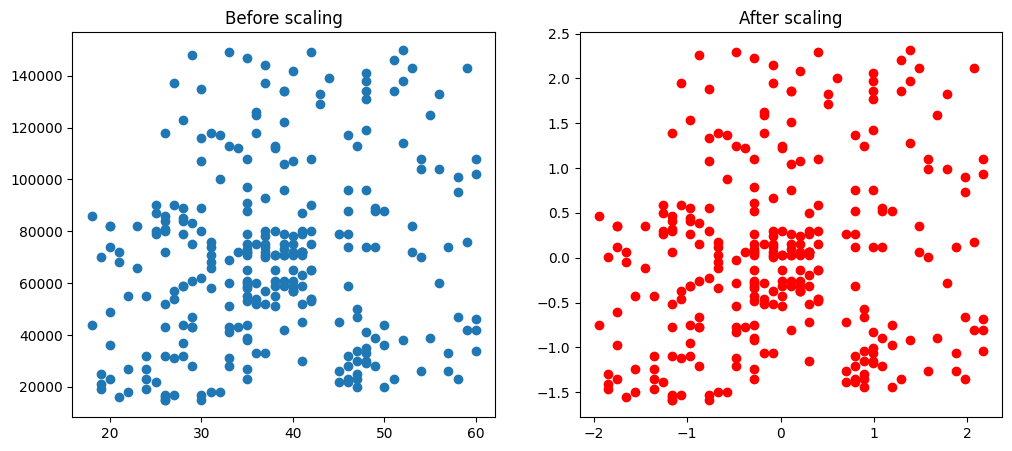

In [84]:
fig , (ax1,ax2) = plt.subplots(ncols = 2, figsize = (12,5))
ax1.scatter(x_train['Age'],x_train['EstimatedSalary'])
ax1.set_title("Before scaling")
ax2.scatter(x_train_scaled['Age'],x_train_scaled['EstimatedSalary'],color='red')
ax2.set_title("After scaling")
plt.show()

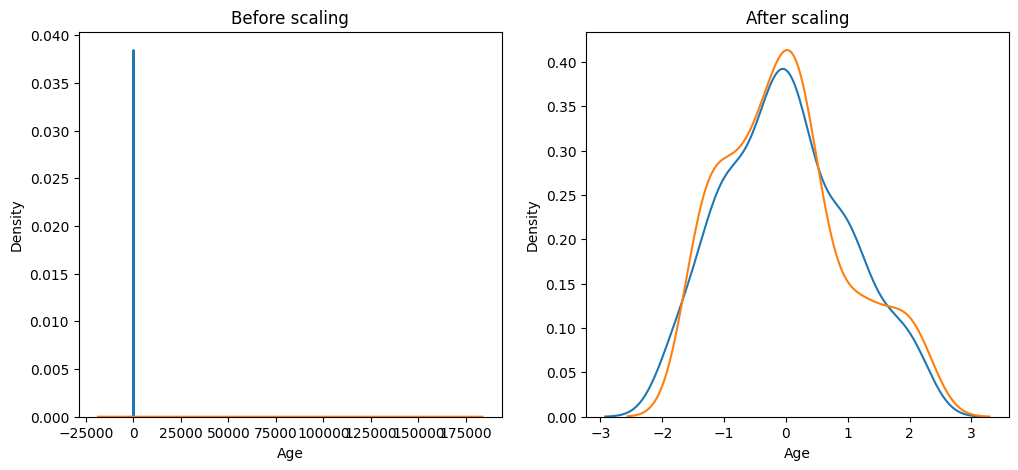

In [88]:
fig2 , (ax1,ax2) = plt.subplots(ncols = 2, figsize = (12,5))
ax1.set_title("Before scaling")
sns.kdeplot(x_train['Age'],ax = ax1)
sns.kdeplot(x_train['EstimatedSalary'],ax = ax1)

ax2.set_title("After scaling")
sns.kdeplot(x_train_scaled['Age'],ax = ax2)
sns.kdeplot(x_train_scaled['EstimatedSalary'],ax = ax2)
plt.show()

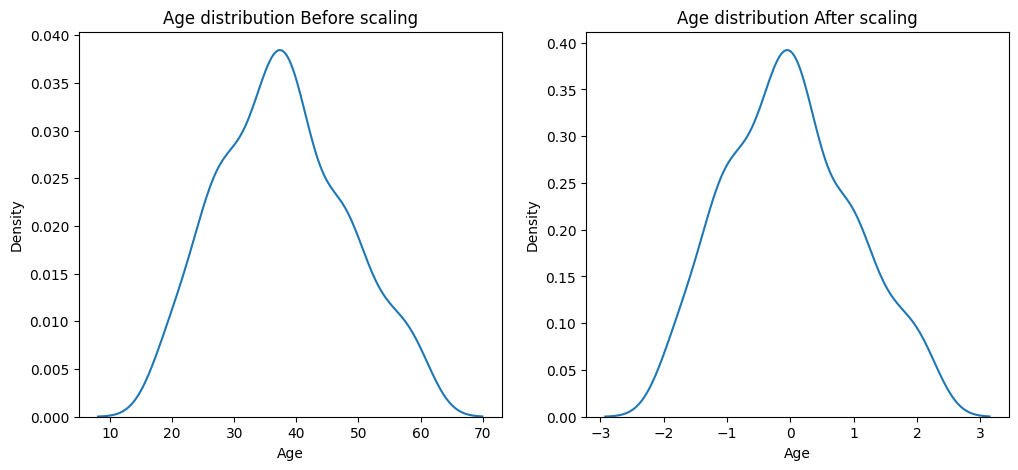

In [90]:
fig2 , (ax1,ax2) = plt.subplots(ncols = 2, figsize = (12,5))
ax1.set_title("Age distribution Before scaling")
sns.kdeplot(x_train['Age'],ax = ax1)
ax2.set_title("Age distribution After scaling")
sns.kdeplot(x_train_scaled['Age'],ax = ax2)
plt.show()

<Axes: title={'center': 'Salary distribution after standardization'}, xlabel='EstimatedSalary', ylabel='Density'>

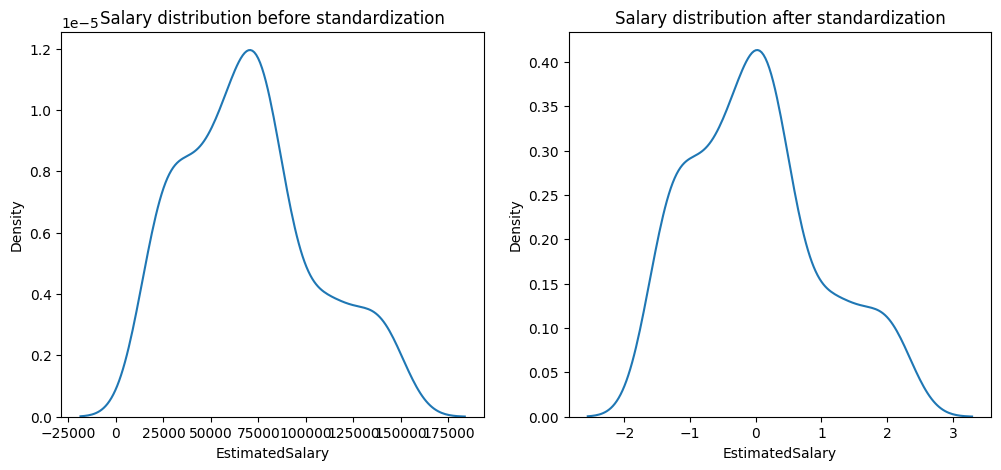

In [93]:
fig , (ax1,ax2) = plt.subplots(ncols = 2 , figsize = (12,5))
ax1.set_title('Salary distribution before standardization')
sns.kdeplot(x_train['EstimatedSalary'],ax = ax1)
ax2.set_title('Salary distribution after standardization')
sns.kdeplot(x_train_scaled['EstimatedSalary'],ax = ax2)